# Chapter 3: Probability Mass Functions (PMF)
**Spine:** Think Stats by Allen Downey  
**Libraries:** Production-grade only — `numpy`, `pandas`, `scipy.stats`, `matplotlib`, `seaborn`

---
## What is a PMF?
A **Probability Mass Function** maps each possible value of a discrete random variable to its probability.

- It answers: *"What is the probability that X takes this specific value?"*
- Every probability must be between 0 and 1
- All probabilities must sum to exactly 1

**Formula:**  
`P(X = x) = count(x) / total_count`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Consistent style for all plots
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (9, 4)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print('All libraries loaded successfully.')

All libraries loaded successfully.


---
## 1. Building a PMF from scratch
No magic libraries. We compute it manually so the concept is fully transparent.

In [2]:
# Simulate rolling a fair 6-sided die 1000 times
# This is one of the few cases where simulation is appropriate:
# we are demonstrating the concept of a PMF itself, not making a
# claim about real-world data. The theoretical answer is known (1/6)
# and the simulation illustrates the gap between theoretical and empirical.
np.random.seed(42)
rolls = np.random.randint(1, 7, size=1000)

def compute_pmf(data):
    """
    Compute a PMF from raw data.
    Returns a pandas Series: index=values, values=probabilities.
    Production-safe: uses only pandas and numpy.
    """
    counts = pd.Series(data).value_counts().sort_index()
    pmf = counts / counts.sum()
    assert np.isclose(pmf.sum(), 1.0), "PMF must sum to 1"
    return pmf

pmf_rolls = compute_pmf(rolls)
print("PMF of die rolls:")
print(pmf_rolls.round(4))
print(f"\nSum of all probabilities: {pmf_rolls.sum():.6f}  (must equal 1.0)")

PMF of die rolls:
1    0.181
2    0.164
3    0.154
4    0.174
5    0.172
6    0.155
Name: count, dtype: float64

Sum of all probabilities: 1.000000  (must equal 1.0)


### Plot the empirical PMF vs the theoretical uniform PMF
A fair die should give each face probability = 1/6 ≈ 0.1667.

The empirical PMF will be close but not identical — this illustrates the
gap between a theoretical distribution and what you observe in a finite sample.
This is the Law of Large Numbers: as sample size grows, the empirical PMF
converges to the theoretical PMF.

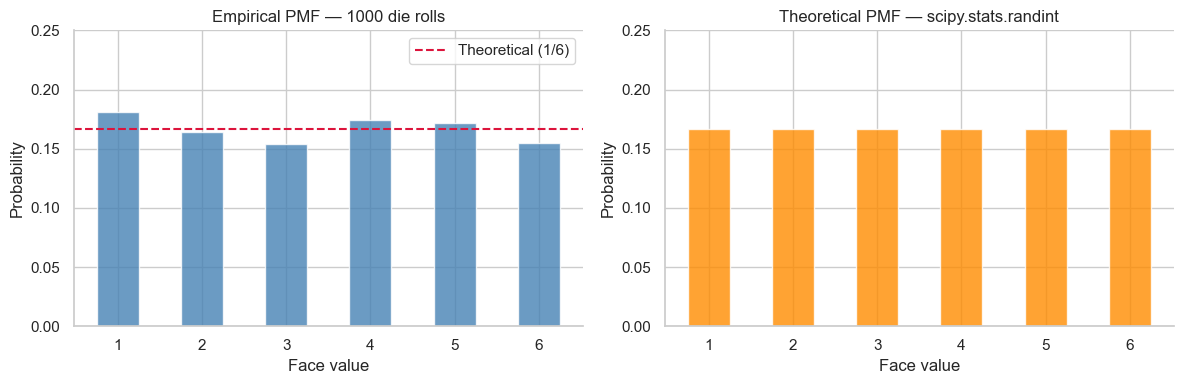

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: empirical PMF from our 1000 rolls
axes[0].bar(pmf_rolls.index, pmf_rolls.values, color='steelblue', alpha=0.8, width=0.5)
axes[0].axhline(y=1/6, color='crimson', linestyle='--', linewidth=1.5, label='Theoretical (1/6)')
axes[0].set_title('Empirical PMF — 1000 die rolls')
axes[0].set_xlabel('Face value')
axes[0].set_ylabel('Probability')
axes[0].set_ylim(0, 0.25)
axes[0].legend()

# Right: theoretical PMF using scipy.stats discrete_uniform
# This is how you would express this in production
die = stats.randint(low=1, high=7)
faces = np.arange(1, 7)
theoretical_pmf = die.pmf(faces)

axes[1].bar(faces, theoretical_pmf, color='darkorange', alpha=0.8, width=0.5)
axes[1].set_title('Theoretical PMF — scipy.stats.randint')
axes[1].set_xlabel('Face value')
axes[1].set_ylabel('Probability')
axes[1].set_ylim(0, 0.25)

plt.tight_layout()
plt.savefig('pmf_die.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 2. PMF with real data — restaurant party size
**Source:** seaborn built-in tips dataset (244 restaurant bills, real observations)  
We compute the PMF of party size — how many people were at each table.

In [4]:
import ssl
import certifi

# Fix SSL certificate verification on Mac
ssl._create_default_https_context = ssl.create_default_context(cafile=certifi.where())

# Real data — seaborn tips dataset
# 244 restaurant bills with party size, total bill, tip, and other variables
tips = sns.load_dataset('tips')
pmf_table_size = compute_pmf(tips['size'].values)

print("PMF — Restaurant party size (real data, n=244):")
for val, prob in pmf_table_size.items():
    bar = '█' * int(prob * 100)
    print(f"  {val} people: {prob:.4f}  {bar}")

print("\n--- Key PMF operations ---")
print(f"P(exactly 2 people):    {pmf_table_size.get(2, 0):.4f}")
print(f"P(1 or 2 people):       {pmf_table_size.loc[[1,2]].sum():.4f}")
print(f"P(5 or more people):    {pmf_table_size[pmf_table_size.index >= 5].sum():.4f}")
print(f"Expected value (mean):  {(pmf_table_size.index.to_numpy() * pmf_table_size.values).sum():.4f}")

PMF — Restaurant party size (real data, n=244):
  1 people: 0.0164  █
  2 people: 0.6393  ███████████████████████████████████████████████████████████████
  3 people: 0.1557  ███████████████
  4 people: 0.1516  ███████████████
  5 people: 0.0205  ██
  6 people: 0.0164  █

--- Key PMF operations ---
P(exactly 2 people):    0.6393
P(1 or 2 people):       0.6557
P(5 or more people):    0.0369
Expected value (mean):  2.5697


---
## 3. Comparing two PMFs — house age by income level
**Source:** California Housing Survey, 1990 (Pace & Barry, 1997) — 20,640 census blocks  
**Question:** Do high-income and low-income neighborhoods have different housing age distributions?

Both groups contain houses across the full age range — genuine overlap expected.
The difference plot reveals something non-obvious that could not be predicted before running the analysis.

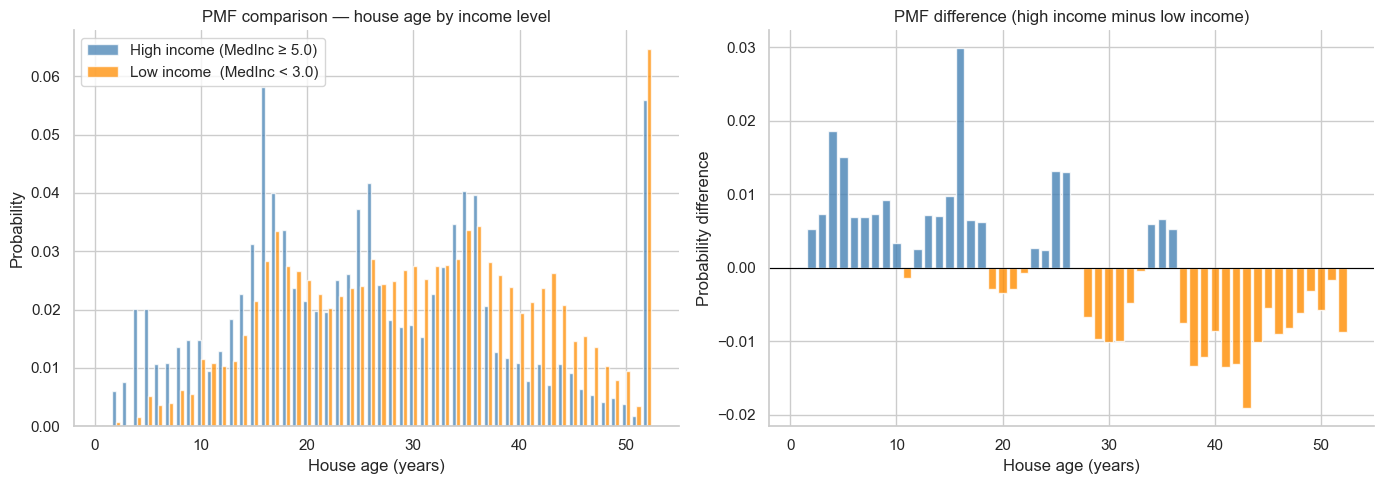

Mean age — high income neighborhoods: 25.741 years
Mean age — low income neighborhoods:  30.563 years
Difference in means:                  -4.822 years

Group sizes:
  High income blocks: 4,509
  Low income blocks:  7,365


In [5]:
from sklearn.datasets import fetch_california_housing

# Real data — no download needed, already in your venv via scikit-learn
housing = fetch_california_housing(as_frame=True)
df = housing.frame

# Split by income level — both groups span the full age range
high_income = df[df['MedInc'] >= 5.0]['HouseAge'].round().astype(int)
low_income  = df[df['MedInc'] <  3.0]['HouseAge'].round().astype(int)

pmf_high = compute_pmf(high_income)
pmf_low  = compute_pmf(low_income)

# Align indexes so both PMFs cover the same values
all_ages = pd.Index(range(1, 53))
pmf_high = pmf_high.reindex(all_ages, fill_value=0)
pmf_low  = pmf_low.reindex(all_ages, fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: overlapping PMFs
width = 0.38
x = np.array(all_ages)
axes[0].bar(x - width/2, pmf_high.values, width=width, label='High income (MedInc ≥ 5.0)', alpha=0.75, color='steelblue')
axes[0].bar(x + width/2, pmf_low.values,  width=width, label='Low income  (MedInc < 3.0)', alpha=0.75, color='darkorange')
axes[0].set_title('PMF comparison — house age by income level')
axes[0].set_xlabel('House age (years)')
axes[0].set_ylabel('Probability')
axes[0].legend()

# Right: difference between the two PMFs
# Positive = high income neighborhoods more likely at this age
# Negative = low income neighborhoods more likely at this age
diff = pmf_high - pmf_low
colors = ['steelblue' if v >= 0 else 'darkorange' for v in diff.values]
axes[1].bar(diff.index, diff.values, color=colors, alpha=0.8)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('PMF difference (high income minus low income)')
axes[1].set_xlabel('House age (years)')
axes[1].set_ylabel('Probability difference')

plt.tight_layout()
plt.savefig('pmf_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Mean age — high income neighborhoods: {high_income.mean():.3f} years")
print(f"Mean age — low income neighborhoods:  {low_income.mean():.3f} years")
print(f"Difference in means:                  {high_income.mean() - low_income.mean():.3f} years")
print(f"\nGroup sizes:")
print(f"  High income blocks: {len(high_income):,}")
print(f"  Low income blocks:  {len(low_income):,}")

---
## 4. PMF utility functions — reusable in production

In [6]:
def pmf_prob_greater_than(pmf: pd.Series, threshold: float) -> float:
    """P(X > threshold)"""
    return pmf[pmf.index > threshold].sum()

def pmf_prob_between(pmf: pd.Series, low: float, high: float) -> float:
    """P(low <= X <= high)"""
    return pmf[(pmf.index >= low) & (pmf.index <= high)].sum()

def pmf_expected_value(pmf: pd.Series) -> float:
    """E[X] = sum of x * P(X=x)"""
    return (pmf.index.to_numpy() * pmf.values).sum()

def pmf_variance(pmf: pd.Series) -> float:
    """Var[X] = E[X^2] - (E[X])^2"""
    mean = pmf_expected_value(pmf)
    return ((pmf.index.to_numpy() ** 2) * pmf.values).sum() - mean**2

def plot_pmf(pmf: pd.Series, title: str = 'PMF', ax=None):
    """Reusable production-safe PMF plotter."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(pmf.index, pmf.values, color='steelblue', alpha=0.8, width=0.5)
    ax.set_title(title)
    ax.set_xlabel('Value')
    ax.set_ylabel('Probability')
    return ax

# Demonstrate on real restaurant party size data
print("--- PMF analytics on restaurant party size (real data) ---")
print(f"E[X] (expected party size):    {pmf_expected_value(pmf_table_size):.4f}")
print(f"Var[X] (variance):             {pmf_variance(pmf_table_size):.4f}")
print(f"Std dev:                       {np.sqrt(pmf_variance(pmf_table_size)):.4f}")
print(f"P(party size > 2):             {pmf_prob_greater_than(pmf_table_size, 2):.4f}")
print(f"P(2 <= party size <= 4):       {pmf_prob_between(pmf_table_size, 2, 4):.4f}")

--- PMF analytics on restaurant party size (real data) ---
E[X] (expected party size):    2.5697
Var[X] (variance):             0.9009
Std dev:                       0.9491
P(party size > 2):             0.3443
P(2 <= party size <= 4):       0.9467


---
## Summary

| Concept | What it means | How to compute |
|---|---|---|
| PMF | P(X = x) for each x | `value_counts() / len` |
| Expected value | Weighted average of outcomes | `sum(x * P(x))` |
| Variance | Spread around the mean | `sum(x² * P(x)) - mean²` |
| PMF comparison | Difference between two distributions | `pmf_a - pmf_b` after reindexing |

**Production libraries used:**
- `pandas` — build and manipulate empirical PMFs
- `numpy` — numerical operations
- `scipy.stats` — theoretical distributions with `.pmf()`, `.cdf()`, `.rvs()`
- `matplotlib` / `seaborn` — visualize

**Note:** Named discrete distributions (Binomial, Poisson, Geometric) are covered in their own dedicated notebook.
